In [12]:
import pandas as pd
import re
import numpy as np

# Filtering firms into ever treated and never treated

### 1. Simple filtering with keywords in job descriptions

In [59]:
# Using dataframes without reposts
df_2021 = pd.read_parquet("../data/Postings/SG-2021-WITHOUT-REPOSTS-W60D.parquet")
df_2022 = pd.read_parquet("../data/Postings/SG-2022-WITHOUT-REPOSTS-W60D.parquet")
df_2023 = pd.read_parquet("../data/Postings/SG-2023-WITHOUT-REPOSTS-W60D.parquet")
df_2024 = pd.read_parquet("../data/Postings/SG-2024-WITHOUT-REPOSTS-W60D.parquet")

In [60]:
df_all = pd.concat([df_2021, df_2022, df_2023, df_2024], axis=0, ignore_index=True)

df_all["post_date"] = pd.to_datetime(df_all["post_date"], errors="coerce")
df_all = df_all.dropna(subset=["post_date"])

Keywords that signal that job postings by firm is hiring for GenAI integrators

In [61]:
GENAI_CORE = [
    "large language model", "llm", "generative ai", "genai",
    "foundation model", "transformer", "gpt", "chatgpt",
    "openai", "claude", "gemini", "llama"
]

GENAI_ENGINEERING = [
    "fine-tuning", "finetuning", "prompt engineering",
    "retrieval augmented generation", "rag",
    "embedding", "vector database"
]

GENAI_GOVERNANCE = [
    "ai governance", "ai safety", "responsible ai",
    "guardrails", "hallucination", "model risk",
    "ai ethics"
]

ROLE_KEYWORDS = [
    "ai engineer", "genai engineer",
    "machine learning engineer",
    "data scientist", "applied scientist"
]

In [62]:
def contains_any(text, keywords):
    if pd.isna(text):
        return False
    text = text.lower()
    return any(k in text for k in keywords)

In [63]:
df_all["genai_core_hit"] = df_all["description"].apply(
    lambda x: contains_any(x, GENAI_CORE)
)

df_all["genai_eng_hit"] = df_all["description"].apply(
    lambda x: contains_any(x, GENAI_ENGINEERING)
)

df_all["genai_gov_hit"] = df_all["description"].apply(
    lambda x: contains_any(x, GENAI_GOVERNANCE)
)

df_all["role_hit"] = df_all["jobtitle"].apply(
    lambda x: contains_any(x, ROLE_KEYWORDS)
)

df_all["is_genai_integrator_posting"] = (
    df_all["genai_core_hit"] |
    ((df_all["genai_eng_hit"] | df_all["genai_gov_hit"]) & df_all["role_hit"])
).astype(int)

In [64]:
FIRM_COL = (
    "ultimate_parent_rcid"
    if "ultimate_parent_rcid" in df_all.columns
    else "company"
)

In [65]:
firm_genai = (
    df_all[df_all["is_genai_integrator_posting"] == 1]
    .groupby(FIRM_COL)["post_date"]
    .min()
    .reset_index()
    .rename(columns={"post_date": "first_genai_integrator_date"})
)

df_all = df_all.merge(firm_genai, on=FIRM_COL, how="left")

df_all["firm_ever_genai_integrator"] = (
    df_all["first_genai_integrator_date"].notna()
).astype(int)

In [66]:
firm_stats = (
    df_all.groupby(FIRM_COL)
    .agg(
        ever_genai=("firm_ever_genai_integrator", "max"),
        first_treat_date=("first_genai_integrator_date", "min"),
        total_postings=("job_id", "count")
    )
    .reset_index()
)

print("Total firms:", len(firm_stats))
print("Treated firms:", firm_stats["ever_genai"].sum())
print("Share treated:", firm_stats["ever_genai"].mean())

print("\nFirst treatment year distribution:")
print(
    firm_stats.loc[firm_stats["ever_genai"] == 1, "first_treat_date"]
    .dt.year
    .value_counts()
    .sort_index()
)

print("\nMean postings by firm type:")
print(
    firm_stats.groupby("ever_genai")["total_postings"]
    .mean()
    .rename({0: "Never treated", 1: "Ever treated"})
)

Total firms: 40378
Treated firms: 3546
Share treated: 0.08782010005448511

First treatment year distribution:
first_treat_date
2021     896
2022     834
2023     714
2024    1102
Name: count, dtype: int64

Mean postings by firm type:
ever_genai
Never treated     15.354474
Ever treated     341.043993
Name: total_postings, dtype: float64


In [67]:
print(df_all[df_all['ultimate_parent_rcid'] == 5827656].head(1))

        job_id     rcid                     company                  rics_k50  \
9  14724463019  5827656  Recruit Express (Malaysia)  Human Resources Services   

                          rics_k200                          rics_k400  \
9  Employment and Staffing Services  Recruitment and Staffing Services   

                                           title_raw  \
9  3 Month Contract Admin Assistant (IMMEDIATE) -...   

                                    title_translated  \
9  3 Month Contract Admin Assistant (IMMEDIATE) -...   

                        role_k10                             role_k25  \
9  Administrative Support and HR  Real Estate and Legal Professionals   

                            role_k50                       role_k100  \
9  Real Estate and Contract Managers  Contract and Proposal Managers   

                        role_k150                          role_k250  \
9  Contract and Proposal Managers  Contract Management Professionals   

                         

Understanding composition of firms that have ever been treated vs. firms that have never been treated

In [70]:
pd.set_option('display.max_columns', None)

In [71]:
# Assumes you already have df_all with:
# - post_date parsed
# - FIRM_COL defined
# - firm_ever_genai_integrator (0/1)
# - is_genai_integrator_posting (0/1)

FIRM_COL = "ultimate_parent_rcid" if "ultimate_parent_rcid" in df_all.columns else "company"
NAME_COL = "company" if "company" in df_all.columns else FIRM_COL  # fallback

# -----------------------------
# 1) Firm-level composition table
# -----------------------------
firm_comp = (
    df_all.groupby(FIRM_COL, as_index=False)
    .agg(
        firm_name=(NAME_COL, lambda s: s.dropna().astype(str).mode().iloc[0] if len(s.dropna()) else ""),
        ever_genai=("firm_ever_genai_integrator", "max"),
        first_genai_date=("first_genai_integrator_date", "min"),
        total_postings=("job_id", "count"),
        total_genai_integrator_posts=("is_genai_integrator_posting", "sum"),
        first_post_date=("post_date", "min"),
        last_post_date=("post_date", "max"),
    )
)

firm_comp["share_genai_integrator_posts"] = (
    firm_comp["total_genai_integrator_posts"] / firm_comp["total_postings"]
).replace([np.inf, -np.inf], np.nan).fillna(0)

firm_comp["active_days"] = (firm_comp["last_post_date"] - firm_comp["first_post_date"]).dt.days

print("Total firms:", firm_comp.shape[0])
print("Ever-GenAI firms:", int(firm_comp["ever_genai"].sum()))
print("Never-GenAI firms:", int((firm_comp["ever_genai"] == 0).sum()))
print("Share ever-GenAI:", float(firm_comp["ever_genai"].mean()))

# -----------------------------
# 2) Lists of firm names (treated vs control)
#    (sorted by total postings so you see the most important first)
# -----------------------------
treated_firms = firm_comp.loc[firm_comp["ever_genai"] == 1].sort_values("total_postings", ascending=False)
control_firms = firm_comp.loc[firm_comp["ever_genai"] == 0].sort_values("total_postings", ascending=False)

treated_names = treated_firms["firm_name"].replace("", np.nan).dropna().unique().tolist()
control_names = control_firms["firm_name"].replace("", np.nan).dropna().unique().tolist()

print("\nTop 30 treated (ever GenAI) firms by postings:")
print(treated_firms[[FIRM_COL, "firm_name", "total_postings", "total_genai_integrator_posts", "first_genai_date"]].head(30).to_string(index=False))

print("\nTop 30 control (never GenAI) firms by postings:")
print(control_firms[[FIRM_COL, "firm_name", "total_postings", "total_genai_integrator_posts"]].head(30).to_string(index=False))

# If you want the full lists:
# treated_names
# control_names

# -----------------------------
# 3) Summary stats comparison (treated vs control)
# -----------------------------
summary = (
    firm_comp.groupby("ever_genai")
    .agg(
        n_firms=(FIRM_COL, "count"),
        mean_total_postings=("total_postings", "mean"),
        median_total_postings=("total_postings", "median"),
        p90_total_postings=("total_postings", lambda x: x.quantile(0.90)),
        mean_genai_posts=("total_genai_integrator_posts", "mean"),
        share_with_any_posts=("total_postings", lambda x: (x > 0).mean()),
        mean_share_genai_posts=("share_genai_integrator_posts", "mean"),
        median_share_genai_posts=("share_genai_integrator_posts", "median"),
        mean_active_days=("active_days", "mean"),
    )
    .rename(index={0: "Never GenAI", 1: "Ever GenAI"})
)

print("\nFirm composition summary (treated vs control):")
print(summary.to_string())

# -----------------------------
# 4) Export for inspection (optional)
# -----------------------------
firm_comp.to_csv("firm_composition_ever_genai_vs_never.csv", index=False)
treated_firms.to_csv("treated_firms_ever_genai.csv", index=False)
control_firms.to_csv("control_firms_never_genai.csv", index=False)

print("\nSaved:")
print("- firm_composition_ever_genai_vs_never.csv")
print("- treated_firms_ever_genai.csv")
print("- control_firms_never_genai.csv")

Total firms: 40378
Ever-GenAI firms: 3546
Never-GenAI firms: 36832
Share ever-GenAI: 0.08782010005448511

Top 30 treated (ever GenAI) firms by postings:
 ultimate_parent_rcid                          firm_name  total_postings  total_genai_integrator_posts first_genai_date
              6695254       Supreme HR Advisory Pte Ltd.           73448                           427       2021-07-22
              5827656         Recruit Express (Malaysia)           48140                           236       2021-03-01
               647749          CapitaLand Group Pte Ltd.           19282                            99       2021-04-12
             93292330                     ABM Industries           18322                           421       2021-12-17
              1133458               Persolkelly Pte Ltd.           18300                           198       2021-04-27
               369884                        Randstad NV           17598                           178       2021-03-02
       

Filtering out recruitment firms

In [72]:
# -----------------------------
# Remove recruitment firms using rics_k400
# -----------------------------

RECRUIT_LABEL = "Recruitment and Staffing Services"
K400_COL = "rics_k400"

df_all = df_all.copy()

# Standardize industry column
df_all[K400_COL] = df_all[K400_COL].astype("string").str.strip()

# Flag recruitment postings
df_all["is_recruitment_k400"] = (df_all[K400_COL] == RECRUIT_LABEL).astype(int)

# Filter them out
df_all_norecruit = df_all[df_all["is_recruitment_k400"] == 0].copy()

# -----------------------------
# Diagnostics
# -----------------------------
print("Original rows:", len(df_all))
print("Rows after removing recruitment firms:", len(df_all_norecruit))
print(
    "Share removed:",
    f"{1 - len(df_all_norecruit) / len(df_all):.2%}"
)

print("\nSample recruitment firms removed:")
print(
    df_all.loc[df_all["is_recruitment_k400"] == 1,
               ["ultimate_parent_company_name", "rics_k400", "rics_k50"]]
    .drop_duplicates()
    .head(10)
)

Original rows: 1774878
Rows after removing recruitment firms: 1285300
Share removed: 27.58%

Sample recruitment firms removed:
         ultimate_parent_company_name                          rics_k400  \
3         Stafflink Services Pte Ltd.  Recruitment and Staffing Services   
8            Faststream Holdings Ltd.  Recruitment and Staffing Services   
9          Recruit Express (Malaysia)  Recruitment and Staffing Services   
15                   People Profilers  Recruitment and Staffing Services   
17  MDE CAPITAL CONSULTANCY PTE. LTD.  Recruitment and Staffing Services   
31                             Mirana  Recruitment and Staffing Services   
34                Spring Professional  Recruitment and Staffing Services   
40                   Will Group, Inc.  Recruitment and Staffing Services   
48              Mtc Staffing Pte Ltd.  Recruitment and Staffing Services   
53                    Anradus Pte Ltd  Recruitment and Staffing Services   

                    rics_k50  
3   H

Panel construction (simple, uniform treatment date is 2023 Q1)

In [56]:
import pandas as pd
import numpy as np

def build_firm_quarter_panel(
    df,
    treat_qtr="2023Q1",
    min_year_qtr="2022Q1",
    save_path=None
):
    """
    Build a firm-quarter panel for DiD analysis.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe (e.g. df_all or df_all_norecruit)
    treat_qtr : str
        Treatment quarter in 'YYYYQ#' format (default: '2023Q1')
    min_year_qtr : str
        Earliest quarter to keep (default: '2022Q1')
    save_path : str or None
        If provided, saves the panel to this .dta path

    Returns
    -------
    panel : pd.DataFrame
        Firm-quarter panel ready for Stata
    """

    df = df.copy()

    # -----------------------------
    # 0) Firm identifier
    # -----------------------------
    FIRM_COL = "ultimate_parent_rcid" if "ultimate_parent_rcid" in df.columns else "company"

    # -----------------------------
    # 1) Dates & quarters
    # -----------------------------
    df["post_date"] = pd.to_datetime(df["post_date"], errors="coerce")
    df = df.dropna(subset=["post_date"])

    df["qtr"] = df["post_date"].dt.to_period("Q")

    # Trim sample start
    min_qtr = pd.Period(min_year_qtr, freq="Q")
    df = df[df["qtr"] >= min_qtr]

    # -----------------------------
    # 2) Firm-quarter aggregation
    # -----------------------------
    firm_q = (
        df.groupby([FIRM_COL, "qtr"])
        .agg(num_postings=("job_id", "count"))
        .reset_index()
    )

    # Balanced firm × quarter grid
    all_firms = pd.Index(df[FIRM_COL].dropna().unique(), name=FIRM_COL)
    all_qtrs = pd.period_range(df["qtr"].min(), df["qtr"].max(), freq="Q", name="qtr")

    full_index = pd.MultiIndex.from_product([all_firms, all_qtrs], names=[FIRM_COL, "qtr"])

    panel = (
        firm_q.set_index([FIRM_COL, "qtr"])
        .reindex(full_index)
        .reset_index()
    )

    panel["num_postings"] = panel["num_postings"].fillna(0).astype("int64")

    # -----------------------------
    # 3) Treatment definition
    # -----------------------------
    firm_treat = (
        df.groupby(FIRM_COL)
        .agg(treated=("firm_ever_genai_integrator", "max"))
        .reset_index()
    )

    panel = panel.merge(firm_treat, on=FIRM_COL, how="left")
    panel["treated"] = panel["treated"].fillna(0).astype("int64")

    TREAT_QTR = pd.Period(treat_qtr, freq="Q")
    panel["post"] = (panel["qtr"] >= TREAT_QTR).astype("int64")
    panel["did"] = panel["treated"] * panel["post"]

    # -----------------------------
    # 4) Outcomes & time variables
    # -----------------------------
    panel["log_postings"] = np.log(panel["num_postings"] + 1)

    panel["year"] = panel["qtr"].dt.year.astype("int64")
    panel["quarter"] = panel["qtr"].dt.quarter.astype("int64")

    panel["t_index"] = (panel["year"] * 4 + panel["quarter"]).astype("int64")
    treat_index = TREAT_QTR.year * 4 + TREAT_QTR.quarter
    panel["relq"] = (panel["t_index"] - treat_index).astype("int64")

    panel["firm_id"] = panel[FIRM_COL].astype("category").cat.codes.astype("int64") + 1

    panel = panel.sort_values(["firm_id", "year", "quarter"]).reset_index(drop=True)

    # -----------------------------
    # 5) Stata-safe variables
    # -----------------------------
    panel["qtr_str"] = panel["qtr"].astype(str)
    panel["tq"] = ((panel["year"] - 1960) * 4 + (panel["quarter"] - 1)).astype("int32")

    panel = panel.drop(columns=["qtr"])

    # -----------------------------
    # 6) Save if requested
    # -----------------------------
    if save_path is not None:
        panel.to_stata(save_path, write_index=False, version=118)
        print("Saved:", save_path)

    return panel

In [ ]:
# WITH recruitment firms
# panel_all = build_firm_quarter_panel(
#     df_all,
#     save_path="../data/firm_quarter_panel_genai_did.dta"
# )

# WITHOUT recruitment firms
panel_norecruit = build_firm_quarter_panel(
    df_all_norecruit,
    save_path="../data/firm_quarter_panel_without_recruiters.dta"
)

Saved: ../data/firm_quarter_panel_without_recruiters.dta


In [73]:
# WITHOUT recruitment firms
panel_norecruit = build_firm_quarter_panel(
    df_all_norecruit,
    min_year_qtr="2021Q1",
    save_path="../data/firm_quarter_panel_without_recruiters_2021.dta"
)

Saved: ../data/firm_quarter_panel_without_recruiters_2021.dta


## EDA to understand 2022 Q3 spike

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = df_all_norecruit.copy()  # or df_all if you want to show contamination first

df["tq"] = pd.PeriodIndex(df["post_date"], freq="Q")
df["treated"] = df["firm_ever_genai_integrator"].astype(int)

In [77]:
df.columns

Index(['job_id', 'rcid', 'company', 'rics_k50', 'rics_k200', 'rics_k400',
       'title_raw', 'title_translated', 'role_k10', 'role_k25', 'role_k50',
       'role_k100', 'role_k150', 'role_k250', 'role_k500', 'role_k1000',
       'role_k1500', 'role_k2500', 'role_k5000', 'role_k10000', 'role_k15000',
       'mapped_role', 'location_raw', 'region', 'country', 'state',
       'metro_area', 'salary', 'post_date', 'remove_date',
       'ultimate_parent_rcid', 'ultimate_parent_company_name', 'onet_code',
       'onet_title', 'remote_type', 'jobtitle', 'description', 'salary_min',
       'salary_max', 'salary_predicted', 'content_hash', 'genai_core_hit',
       'genai_eng_hit', 'genai_gov_hit', 'role_hit',
       'is_genai_integrator_posting', 'first_genai_integrator_date',
       'firm_ever_genai_integrator', 'is_recruitment_k400', 'tq', 'treated'],
      dtype='object')

In [78]:
pre = df[df["tq"] < "2023Q1"]

firm_size_pre = (
    pre.groupby(["company", "treated"])
       .size()
       .reset_index(name="num_postings_pre")
)

firm_size_pre.groupby("treated")["num_postings_pre"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
)

,count,mean,std,min,25%,50%,75%,90%,95%,max
treated,,,,,,,,,,
0,25806.0,8.567891,22.474491,1.0,1.0,3.0,7.0,19.0,32.0,912.0
1,3977.0,86.579583,347.150388,1.0,4.0,13.0,50.0,169.0,321.2,9478.0


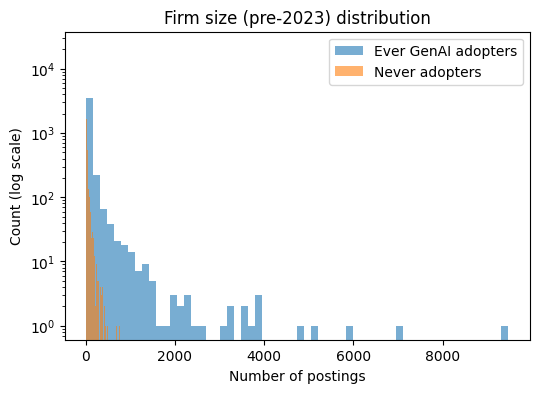

In [80]:
plt.figure(figsize=(6,4))
plt.hist(firm_size_pre[firm_size_pre["treated"]==1]["num_postings_pre"], bins=60, alpha=0.6, label="Ever GenAI adopters")
plt.hist(firm_size_pre[firm_size_pre["treated"]==0]["num_postings_pre"], bins=60, alpha=0.6, label="Never adopters")
plt.yscale("log")
plt.legend()
plt.title("Firm size (pre-2023) distribution")
plt.xlabel("Number of postings")
plt.ylabel("Count (log scale)")
plt.show()

In [89]:
top = (
    df[df["treated"] == 1]
    .groupby("company")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

top

company
ABM Industries                        18322
Randstad NV                           17424
University of Singapore               11794
Citigroup Foundation                   9365
RecruitPedia                           8966
DBS Bank Ltd.                          8584
Standard Chartered Bank Ltd.           7840
United Overseas Bank Ltd. (Broker)     7512
St Engineering Pte Ltd.                7392
Singapore Telecommunications Ltd.      6987
NodeFlair Pte Ltd.                     6604
Nanyang Technological University       6288
TikTok, Inc.                           6026
ITCAN                                  5999
Gmp Group SA                           5944
Talent Traders                         5940
Hemmersbach GmbH & Co. KG              5421
Aber Care Pte Ltd.                     5016
OCBC Bank (Malaysia) Bhd.              4637
Micron Technology, Inc.                4221
dtype: int64

In [85]:
agg = (
    df.groupby(["tq", "treated"])
      .agg(
          postings=("company", "size"),
          firms=("company", "nunique")
      )
      .reset_index()
)

agg["postings_per_firm"] = agg["postings"] / agg["firms"]

c:\Users\teomi\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\teomi\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\teomi\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\teomi\AppData\Local\Programs\Python\Python310\lib\site-p

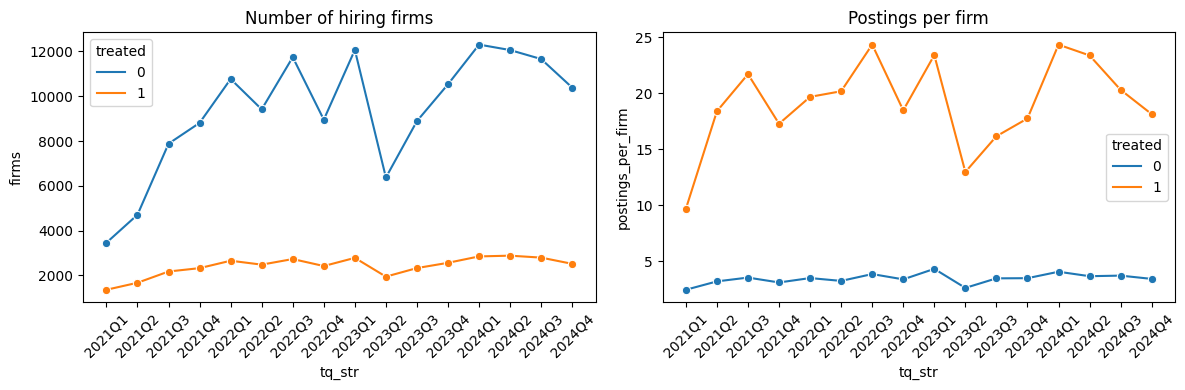

In [87]:
agg_plot = agg.copy()
agg_plot["tq_str"] = agg_plot["tq"].astype(str)

fig, ax = plt.subplots(1,2, figsize=(12,4), sharex=True)

sns.lineplot(data=agg_plot, x="tq_str", y="firms", hue="treated", marker="o", ax=ax[0])
ax[0].set_title("Number of hiring firms")
ax[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=agg_plot, x="tq_str", y="postings_per_firm", hue="treated", marker="o", ax=ax[1])
ax[1].set_title("Postings per firm")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()